In [3]:
import pandas as pd
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import sys
from tensorflow.keras.utils import to_categorical
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from collections import defaultdict, Counter
import ast
from Levenshtein import distance
from lstmTRVR_8_16 import *

I0000 00:00:1781095627.887482   38091 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6189 MB memory:  -> device: 0, name: NVIDIA RTX 2000 Ada Generation Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [7]:
# GLOBAL STYLE SETTINGS (run once)

plt.rcParams.update({

    # --- FONT SIZES ---
    "font.size": 24,              # base font size
    "axes.titlesize": 20,         # title
    "axes.labelsize": 36,         # x/y labels
    "xtick.labelsize": 36,
    "ytick.labelsize": 36,
    "legend.fontsize": 16,

    # --- LINES ---
    "lines.linewidth": 5,
    "lines.markersize": 16,

    # --- FIGURE / AXIS ---
    "figure.figsize": (8, 6),
    "figure.dpi": 120,
    "axes.linewidth": 1.5,        # thicker axis spines

    # --- TICKS ---
    "xtick.major.size": 15,
    "xtick.major.width": 3,
    "ytick.major.size": 15,
    "ytick.major.width": 3,

    # --- LEGEND ---
    "legend.frameon": True,
    "legend.framealpha": 0.8,
    "legend.fancybox": True,

    # --- GRID (optional) ---
    #"axes.grid": True,
    #"grid.alpha": 0.3,
})


In [8]:
Xtest=np.load('X_test.npy')
ytest=np.load('y_test.npy')
print(Xtest.shape)
seq_lengths=np.int64(Xtest[:,0,-1])
print(seq_lengths[0])
TR=[one_hot_decode(x[:seq_lengths[i],:4])[::-1] for i,x in enumerate(Xtest)]
VR=[one_hot_decode(x[:seq_lengths[i],:4])[::-1] for i,x in enumerate(ytest)]
VR_gen=generate_sequences(TR)

(22800, 245, 6)
135


2026-06-10 14:50:59.905414: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 111720000 exceeds 10% of free system memory.
2026-06-10 14:50:59.981487: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 111720000 exceeds 10% of free system memory.
2026-06-10 14:51:05.714052: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90501


713/713 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step


2026-06-10 14:51:25.025505: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 134064000 exceeds 10% of free system memory.
2026-06-10 14:51:25.204785: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 44688000 exceeds 10% of free system memory.
Generating sequence: 100%|████████████████████| 245/245 [14:59<00:00,  3.67s/it]


# Fig 6 (a) Motif biases

In [10]:
def motif_change_probability(seq_list1, seq_list2, motif_length=3):
    # Ensure both lists are of the same length
    assert len(seq_list1) == len(seq_list2), "Sequence lists must be of the same length."
    
    # Dictionary to count changes and total occurrences for each motif
    motif_counts = defaultdict(lambda: {'changes': 0, 'total': 0})

    # Iterate over paired sequences
    for seq1, seq2 in zip(seq_list1, seq_list2):
        # Ensure sequences are the same length
        assert len(seq1) == len(seq2), "Paired sequences must be of the same length."
        
        # Scan motifs in each sequence
        for i in range(len(seq1) - motif_length + 1):
            # Extract motifs of length 3
            motif1 = seq1[i:i+motif_length]
            motif2 = seq2[i:i+motif_length]
            
            # Focus on the central position of the motif
            center_pos = motif_length // 2
            motif_counts[motif1]['total'] += 1
            
            # Check if the central nucleotide differs
            if motif1[center_pos] != motif2[center_pos]:
                motif_counts[motif1]['changes'] += 1

    # Calculate the probability of change for each motif
    motif_probabilities = {
        motif: counts['changes'] / counts['total'] if counts['total'] > 0 else 0
        for motif, counts in motif_counts.items()
    }
    
    return motif_probabilities

In [11]:
dic_original=motif_change_probability(TR, VR, motif_length=3)
dic_gen=motif_change_probability(TR, VR_gen, motif_length=3)

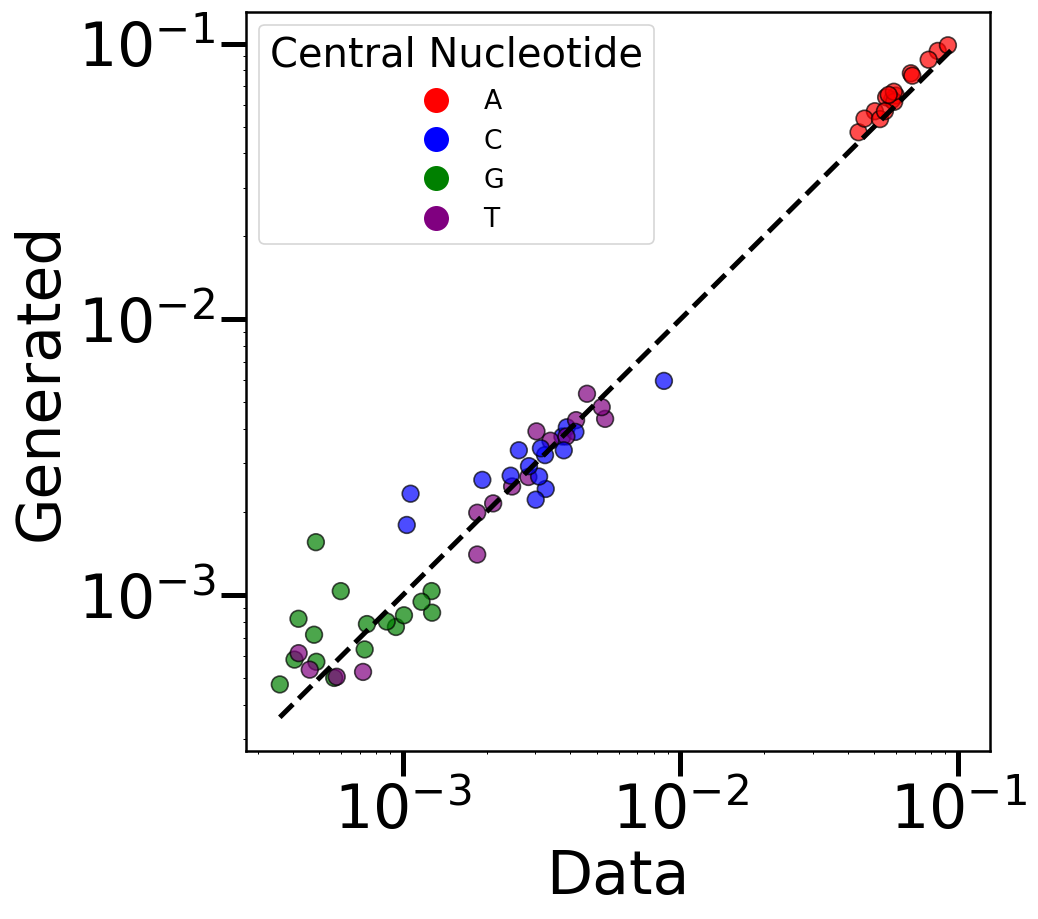

In [12]:
# Define color mapping for central nucleotides
color_map = {'A': 'red', 'C': 'blue', 'G': 'green', 'T': 'purple'}

# Extract data
P1 = [dic_original[k] for k in dic_original.keys()]
P2 = [dic_gen[k] for k in dic_original.keys()]
central_nucleotides = [k[1] for k in dic_original.keys()]  # Middle letter of motif

# Assign colors based on the central nucleotide
colors = [color_map[n] for n in central_nucleotides]

# Create figure
plt.figure(figsize=(8, 8))

# Scatter plot with colors (No lines)
plt.scatter(P1, P2, c=colors, alpha=0.7, edgecolors='k', s=100)

# Labels and aesthetics
plt.xlabel('Data')
plt.ylabel('Generated')
plt.xscale('log')
plt.yscale('log')

# Increase tick sizes
plt.xticks()
plt.yticks()

# Add identity line
x = np.linspace(min(P1 + P2), max(P1 + P2), 100)
plt.plot(x, x, '--k', linewidth=3)

# Remove grid and lines
plt.grid(False)

# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[n], label=n) for n in color_map]
plt.legend(handles=legend_elements, title="Central Nucleotide")

# Show plot
#plt.savefig('Motif_size_3.svg')

# Fig 6 (b)

In [13]:
dic_original=motif_change_probability(TR, VR, motif_length=5)
dic_gen=motif_change_probability(TR, VR_gen, motif_length=5)

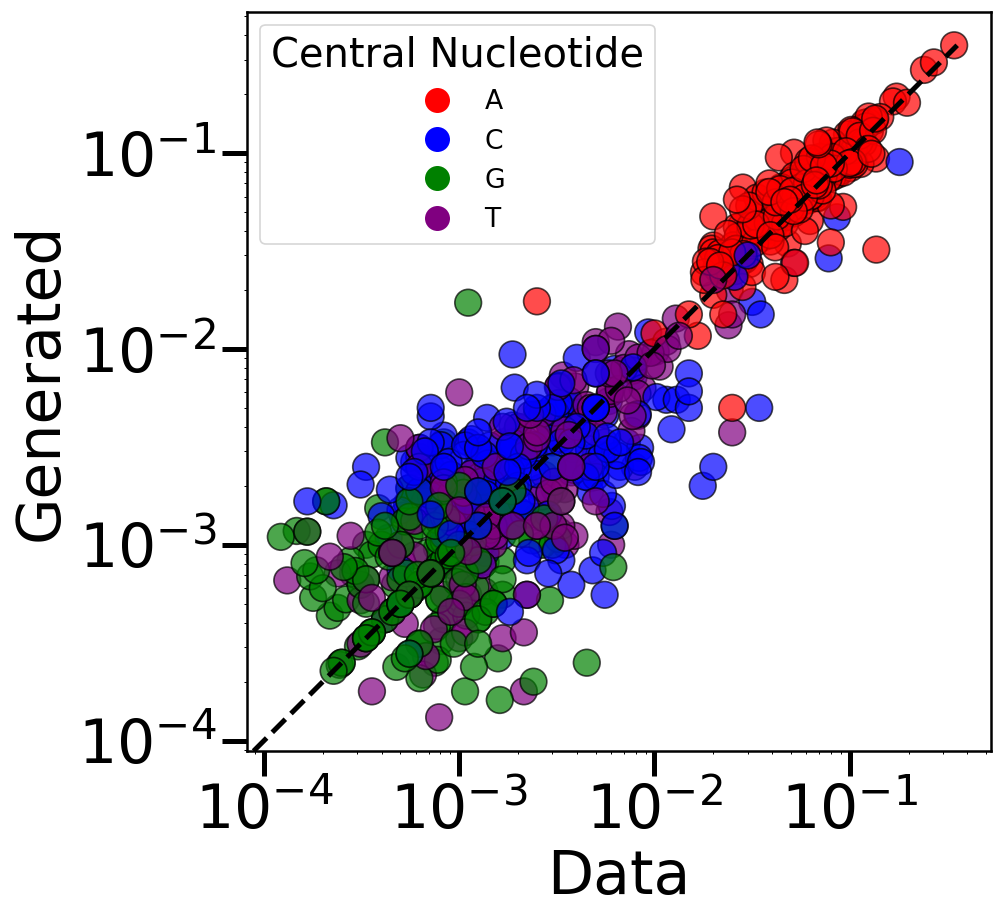

In [14]:


# Define color mapping for central nucleotides
color_map = {'A': 'red', 'C': 'blue', 'G': 'green', 'T': 'purple'}

# Extract data
P1 = [dic_original[k] for k in dic_original.keys()]
P2 = [dic_gen[k] for k in dic_original.keys()]
central_nucleotides = [k[2] for k in dic_original.keys()]  # Middle letter of motif

# Assign colors based on the central nucleotide
colors = [color_map[n] for n in central_nucleotides]

# Create figure
plt.figure(figsize=(8, 8))
# Scatter plot with colors (No lines)
plt.scatter(P1, P2, c=colors, alpha=0.7, edgecolors='k')

# Labels and aesthetics
plt.xlabel('Data')
plt.ylabel('Generated')
plt.xscale('log')
plt.yscale('log')

# Increase tick sizes
plt.xticks()
plt.yticks()

# Add identity line
x = np.linspace(min(P1 + P2), max(P1 + P2), 100)
plt.plot(x, x, '--k', linewidth=3)

# Remove grid and lines
plt.grid(False)

# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[n], label=n) for n in color_map]
plt.legend(handles=legend_elements, title="Central Nucleotide")

# Show plot
#plt.savefig('Motif_size_5.svg')
#plt.show()


# Fig 6 (c)

In [15]:
def mutation_probability_with_dist(seq_list1, seq_list2,dist=1,mut=True):
    # Ensure both lists are of the same length
    assert len(seq_list1) == len(seq_list2), "Sequence lists must be of the same length."
    
    # Dictionary to store counts of mutations based on nucleotide and position
    mutation_counts = defaultdict(lambda: {'mutations': 0, 'total': 0})

    # Iterate over paired sequences
    for seq1, seq2 in zip(seq_list1, seq_list2):
        # Ensure sequences are the same length
        assert len(seq1) == len(seq2), "Paired sequences must be of the same length."
        
        # Scan each position in the sequences
        for i in range(len(seq1)-dist):
            if ((seq1[i+dist]!=seq2[i+dist])==mut):
                mutation_counts[seq1[i]]['total']+=1
                mutation_counts[seq1[i]]['mutations']+=seq1[i]!=seq2[i]
    mutation_probabilities = {
        key: counts['mutations'] / counts['total'] if counts['total'] > 0 else 0
        for key, counts in mutation_counts.items()
    }
    
    return mutation_probabilities

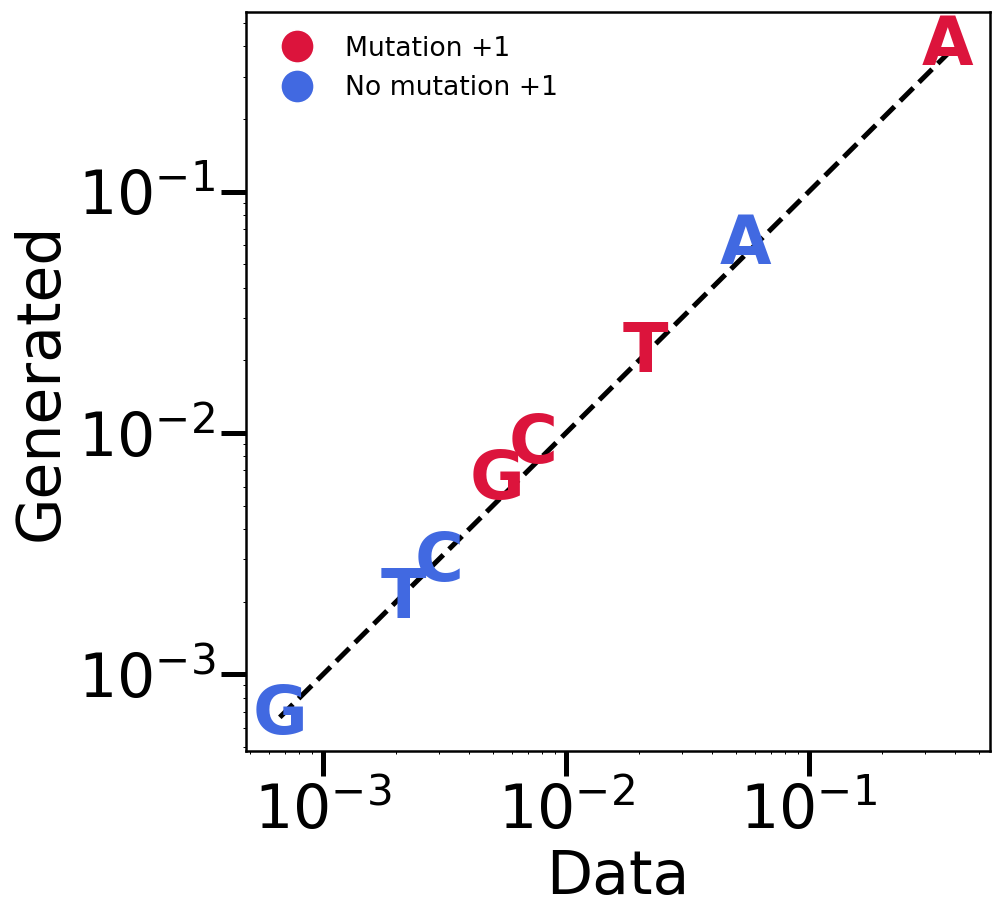

In [16]:
dic_original=mutation_probability_with_dist(TR, VR)
dic_gen=mutation_probability_with_dist(TR, VR_gen)

dic_original_nomut=mutation_probability_with_dist(TR, VR,mut=False)
dic_gen_nomut=mutation_probability_with_dist(TR, VR_gen,mut=False)

# Define colors for different mutation categories
colors = {'Mutation +1': 'crimson', 'No mutation +1': 'royalblue'}

# Extract data
P1 = [dic_original[k] for k in dic_original.keys()]
P2 = [dic_gen[k] for k in dic_original.keys()]
nucleotides1 = list(dic_original.keys())  # Nucleotide identity

P3 = [dic_original_nomut[k] for k in dic_original_nomut.keys()]
P4 = [dic_gen_nomut[k] for k in dic_original_nomut.keys()]
nucleotides2 = list(dic_original_nomut.keys())  # Nucleotide identity

# Create figure
plt.figure(figsize=(8, 8))

# Identity line
x = np.linspace(min(P1 + P2 + P3 + P4), max(P1 + P2 + P3 + P4), 20)
plt.plot(x, x, '--k', linewidth=3)

# Plot letters instead of points
for x, y, letter in zip(P1, P2, nucleotides1):
    plt.text(x, y, letter, fontsize=40, color=colors['Mutation +1'], ha='center', va='center', fontweight='bold')

for x, y, letter in zip(P3, P4, nucleotides2):
    plt.text(x, y, letter, fontsize=40, color=colors['No mutation +1'], ha='center', va='center', fontweight='bold')



# Labels and aesthetics
plt.xlabel('Data')
plt.ylabel('Generated')
plt.xscale('log')
plt.yscale('log')

# Increase tick sizes
plt.xticks()
plt.yticks()

# Remove grid for cleaner look
plt.grid(False)

# Improved legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['Mutation +1'], markersize=20, label='Mutation +1'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['No mutation +1'], markersize=20, label='No mutation +1')
]
plt.legend(handles=legend_elements, frameon=False, loc='upper left')
#plt.savefig('Mutation1.svg')
# Show plot
#plt.show()


# Fig 6 (d)

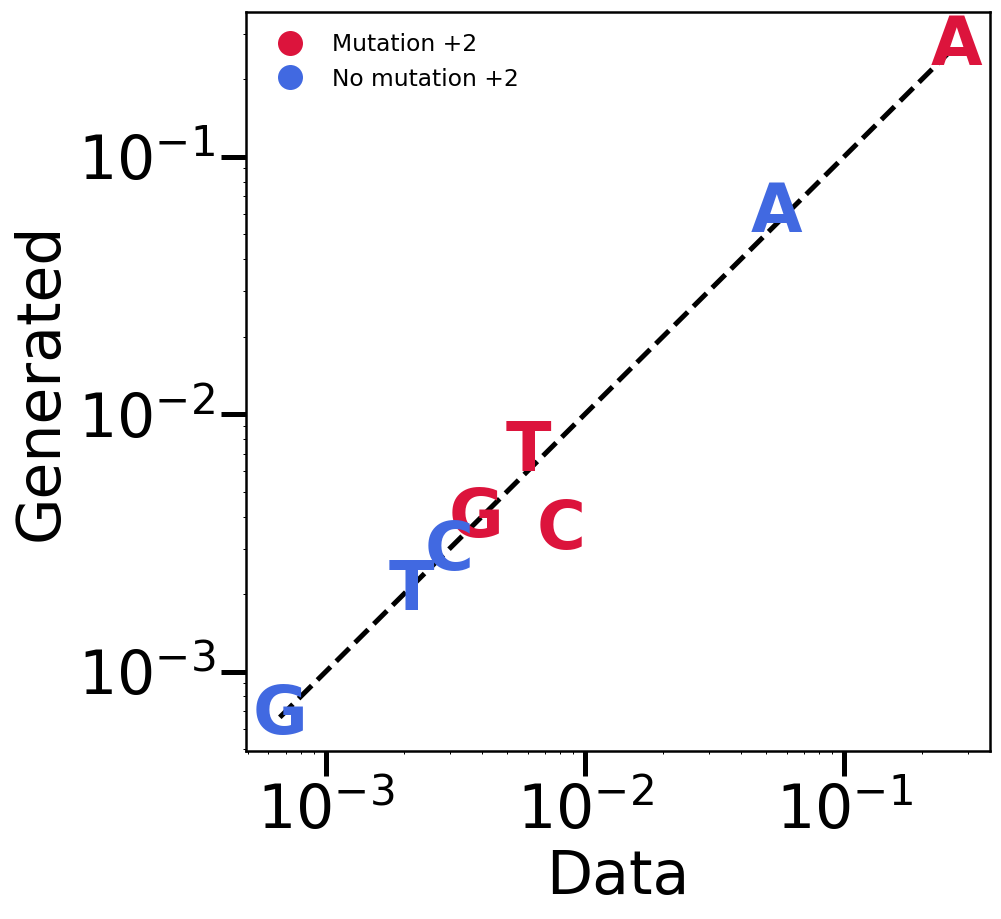

In [17]:
dic_original=mutation_probability_with_dist(TR, VR,2)
dic_gen=mutation_probability_with_dist(TR, VR_gen,2)

dic_original_nomut=mutation_probability_with_dist(TR, VR,mut=False)
dic_gen_nomut=mutation_probability_with_dist(TR, VR_gen,mut=False)

# Define colors for different mutation categories
colors = {'Mutation +2': 'crimson', 'No mutation +2': 'royalblue'}

# Extract data
P1 = [dic_original[k] for k in dic_original.keys()]
P2 = [dic_gen[k] for k in dic_original.keys()]
nucleotides1 = list(dic_original.keys())  # Nucleotide identity

P3 = [dic_original_nomut[k] for k in dic_original_nomut.keys()]
P4 = [dic_gen_nomut[k] for k in dic_original_nomut.keys()]
nucleotides2 = list(dic_original_nomut.keys())  # Nucleotide identity

# Create figure
plt.figure(figsize=(8, 8))

# Identity line
x = np.linspace(min(P1 + P2 + P3 + P4), max(P1 + P2 + P3 + P4), 20)
plt.plot(x, x, '--k', linewidth=3)

# Plot letters instead of points
for x, y, letter in zip(P1, P2, nucleotides1):
    plt.text(x, y, letter, fontsize=40, color=colors['Mutation +2'], ha='center', va='center', fontweight='bold')

for x, y, letter in zip(P3, P4, nucleotides2):
    plt.text(x, y, letter, fontsize=40, color=colors['No mutation +2'], ha='center', va='center', fontweight='bold')



# Labels and aesthetics
plt.xlabel('Data')
plt.ylabel('Generated')
plt.xscale('log')
plt.yscale('log')

# Increase tick sizes
plt.xticks()
plt.yticks()

# Remove grid for cleaner look
plt.grid(False)

# Improved legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['Mutation +2'], label='Mutation +2'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['No mutation +2'], label='No mutation +2')
]
plt.legend(handles=legend_elements, fontsize=14, frameon=False, loc='upper left')

# Show plot

plt.savefig('Mutation2.svg')

plt.show()


# Fig 6 (e) 

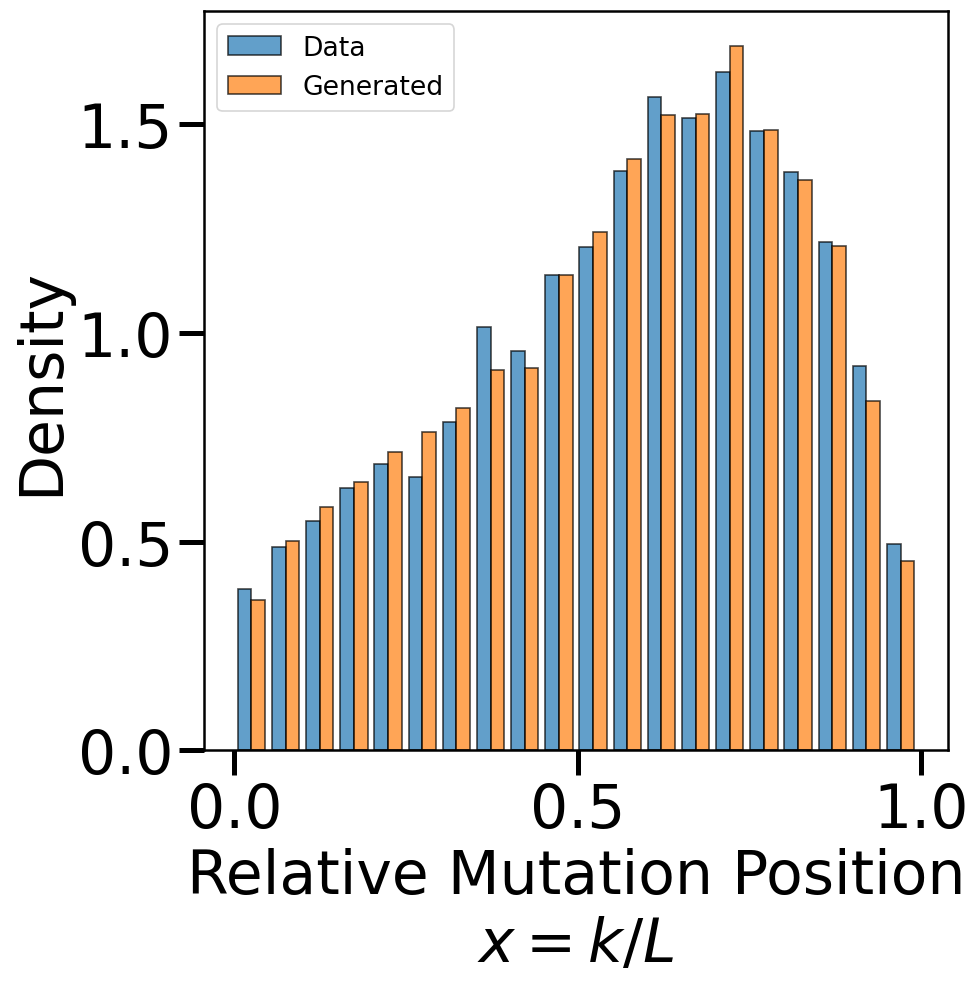

In [18]:
def get_mutation_positions(seq1, seq2):
    """Return the positions where seq1 and seq2 differ."""
    boo=np.array([seq1[i]!=seq2[i] for i in range(len(seq1))])
    return np.arange(len(boo))[boo]

def normalize_positions(positions, L):
    """Normalize positions by sequence length L."""
    return [p / L for p in positions]


# Compare TR/VR
mutation_positions_TR_VR = []
for tr, vr in zip(TR, VR):
    positions = get_mutation_positions(tr, vr)
    L = len(tr)
    normalized_positions = normalize_positions(positions, L)
    mutation_positions_TR_VR.extend(normalized_positions)

# Compare TR/VR_gen
mutation_positions_TR_VR_gen = []
for tr, vr_gen in zip(TR, VR_gen):
    positions = get_mutation_positions(tr, vr_gen)
    L = len(tr)
    normalized_positions = normalize_positions(positions, L)
    mutation_positions_TR_VR_gen.extend(normalized_positions)

# Plot histograms
plt.figure(figsize=(8, 8))
plt.hist(
    [mutation_positions_TR_VR, mutation_positions_TR_VR_gen],
    bins=20,
    label=["Data", "Generated"],
    color=["#1f77b4", "#ff7f0e"],  # Blue and Orange (Matplotlib default colors)
    alpha=0.7,  # Slightly transparent for better visibility
    density=True,
    edgecolor="black",  # Add edge color for clarity
)
plt.xlabel("Relative Mutation Position\n"+r"$x = k/L$")
plt.ylabel("Density")
plt.legend()
plt.savefig('Position_dependence.svg')

# Fig 6 (f)

In [19]:
def mutational_profile_from_counter(TR, VR):
    """
    TR: str (reference sequence)
    VR: Counter({sequence: count})
    
    Returns:
        mutation_freq: dict[base][position] = % mutated UMIs
    """
    L = len(TR)
    total_umis = sum(VR.values())

    # Count mutations per position
    mutation_counts = {i: Counter() for i in range(L)}

    for seq, count in VR.items():
        for i, (ref, obs) in enumerate(zip(TR, seq)):
            if ref != obs:
                mutation_counts[i][obs] += count

    # Convert to percentages
    mutation_types = ["A", "T", "G", "C"]
    mutation_freq = {b: np.zeros(L) for b in mutation_types}

    for i in range(L):
        for b in mutation_types:
            mutation_freq[b][i] = (
                mutation_counts[i][b] / total_umis * 100
                if b in mutation_counts[i]
                else 0
            )

    return mutation_freq

def plot_mutational_profile(TR, mutation_freq):
    mutation_palette = {
        "A": "#F28E2B",
        "T": "r",
        "G": "g",
        "C": "b"
    }

    positions = np.arange(len(TR))
    bottom = np.zeros(len(TR))

    plt.figure(figsize=(14, 4))

    for base in ["A", "T", "G", "C"]:
        plt.bar(
            positions,
            mutation_freq[base],
            bottom=bottom,
            color=mutation_palette[base],
            label=base
        )
        bottom += mutation_freq[base]

    plt.xticks(
        ticks=positions,
        labels=list(TR),
        fontsize=14,
        fontfamily="monospace"
    )
    plt.xlabel("Position in Sequence", fontsize=16)
    plt.ylabel("% mutated UMIs", fontsize=16)
    plt.title("Mutational Profile Across TR")
    plt.legend(title="Mutation Type")
    plt.ylim(0, 60)
    plt.tight_layout()


In [20]:
df = pd.read_csv("../Summary_all.csv",index_col=False)
# Convert stringified dicts to dicts (once)
df['Mutants'] = df['Mutants'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
df_Lib2=df[df['Library']=='Lib_2']
df_Lib2=df_Lib2[df_Lib2['percentage_mutants']>3]

TR=list(df_Lib2['TR'])[0]
VR=df[df['TR']==TR]

# Precompute weighted value
VR['weighted_mut'] = VR['percentage_mutants'] * VR['TR_count']

VR = (
    VR
    .groupby(['TR', 'Library'], as_index=False)
    .agg(
        TR_count=('TR_count', 'sum'),
        weighted_mut=('weighted_mut', 'sum'),
        Mutants=('Mutants', lambda x: dict(sum((Counter(d) for d in x), Counter())))
    )
)

# Final weighted average
VR['percentage_mutants'] = VR['weighted_mut'] / VR['TR_count']

# Cleanup
VR = VR.drop(columns='weighted_mut')
VR=VR['Mutants'][0]



2026-06-10 15:07:48.134127: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 49848000 exceeds 10% of free system memory.


779/779 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step


Generating sequence: 100%|████████████████████| 100/100 [07:15<00:00,  4.36s/it]


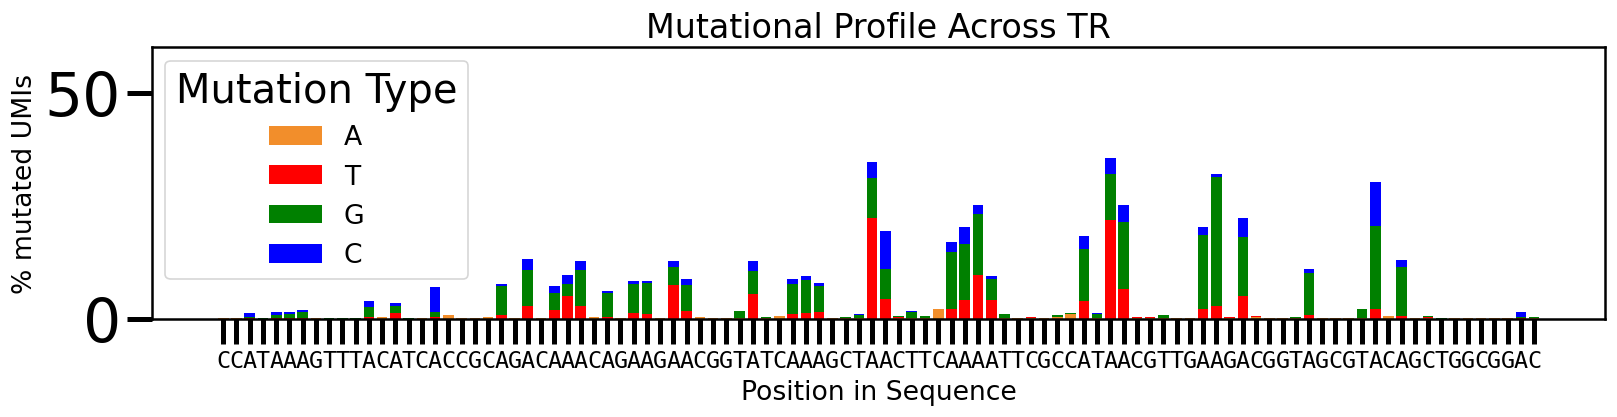

In [21]:
LSTM_VR=generate_sequences_oneTR(TR,n=int(np.sum(list(VR.values()))))
LSTM_VR=Counter(LSTM_VR)
mutation_freq = mutational_profile_from_counter(TR, LSTM_VR)
plot_mutational_profile(TR, mutation_freq)
#plt.savefig('Test_profile_LSTM.svg')